In [33]:
import requests
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
#download the new modern 2025 urban dictionary dataset, acquired from hugging face
# 1. Define the direct download URL and a SAFE filename (no colons!)
url = "https://huggingface.co/datasets/georgiyozhegov/urbandictionary-raw/resolve/main/urbandictionary-join-2025-04-20-22:44:35.413022.jsonl"
local_filename = "urbandictionary_2025_fixed.jsonl"

# 2. Download using requests to bypass the Hugging Face Hub's lock-file logic
print(f"Downloading to {local_filename}...")
response = requests.get(url, stream=True)
response.raise_for_status() # Check for errors

with open(local_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

print("Download complete!")

# 3. Load the data
# Note: Urban Dictionary data can be huge, so we use 'lines=True' for JSONL
urban = pd.read_json(local_filename, lines=True)
print(f"Loaded {len(urban)} rows.")
print(urban.head())

Download complete!
Loaded 152941 rows.
         id                              time  score        word  \
0  14854051  2020-04-03T12:15:17.526000+00:00     -1  Wet pickle   
1  14384824  2019-11-04T01:39:39.139000+00:00     15    Shlumped   
2  17203691  2022-05-03T17:19:17.808000+00:00     10        Ciro   
3  15348795  2020-09-29T20:38:22.555000+00:00      0       AOIDH   
4  10607642  2016-12-08T00:52:16.576000+00:00      5    Emmalene   

                                          definition  \
0                It's you lily. You're a wet pickle.   
1  When someone falls asleep or passes out during...   
2  The sweetest girl you'll ever meet. She is ado...   
3  AUDIO OR IT, DIDN'T, HAPPEN , JUST LIKE, POIDH...   
4  Emmalene is Short but she don't care, she is l...   

                                             example  
0  Today, I went and saw the wet pickle! She's go...  
1  "Have you seen James recently?" "Ya, he's shlu...  
2  I'm sure that girl is total Ciro.\r\nI met thi.

In [2]:
print("Dataset Summary")
print(f'{len(urban.columns)} columns: {urban.columns}')
print(f'Number of entries: {len(urban)}')

Dataset Summary
6 columns: Index(['id', 'time', 'score', 'word', 'definition', 'example'], dtype='str')
Number of entries: 152941


In [3]:
#Example of how to search specific entries
term = "rizz"
result = urban[urban['word'].str.contains(term, case=False, na=False)]
#result at this point will contain all data about the term you searched for, including any variants of the word
#for example:
print(result['word']) #is all urban dictionary entries that contain some variant of "Rizz"
print()
#to get a very specifc entry of the same spelling we do:
specific_urban = urban[urban['word'] == term]
print(specific_urban[['word', 'definition']])
print()
#the words all have a set of definitions ordered by score (this represents the thumbs up or likes)
#if more than 1 definition exists you can iterate through it here:
top_def = specific_urban.sort_values(by='score', ascending=False).iloc[0]
print(f"Word: {top_def['word']}\nDefinition: {top_def['definition']}")

84                Tee Rizzley
1228                  grizzle
3218                     Rizz
4526            drizzylations
4536                 Drizzalt
                 ...         
148074           Skibidi Rizz
148551      The Unspoken Rizz
149342                  Frizz
149948     Rizzual Harassment
150514    Grizzly Wintergreen
Name: word, Length: 84, dtype: str

        word                                         definition
143914  rizz  A rizz is where someone smokes tobacco out of ...

Word: rizz
Definition: A rizz is where someone smokes tobacco out of a bong. There are rizz bongs as well as tobacco bongs, and the reason people usually have a separate bong for taking a rizz rather than smoking their weed is because the tobacco usually makes the bong taste nasty, unlike weed, which tastes amazing. It is different than a rizzle, which is where someone smokes the combination of that lovely green with a splash of tobacco. Rizzles make the stoned feeling happen a little faster,last a l

In [4]:
#now we move on to establishing a new non urban dataset, specifically this is an English dictionary from 2024
#also acquired from huggingface
dataset = load_dataset("npvinHnivqn/EnglishDictionary")

# Convert the 'train' split to a Pandas DataFrame
dic = pd.DataFrame(dataset['train'])

# Peek at the structure
print(dic.head())

Generating train split: 100%|██████████| 111601/111601 [00:00<00:00, 451323.22 examples/s]


         word                                         definition
0           a  the first letter of the english and of many ot...
1         a 1  a registry mark given by underwriters (as at l...
2       a b c  the first three letters of the alphabet, used ...
3  a cappella  in church or chapel style; -- said of composit...
4  a fortiori                              with stronger reason.


In [5]:
print("Dataset Summary")
print(f'{len(dic.columns)} columns: {dic.columns}')
print(f'Number of entries: {len(dic)}')
#as we can see the columns arent really set up, we will need to do some manual parsing

Dataset Summary
2 columns: Index(['word', 'definition'], dtype='str')
Number of entries: 111601


In [6]:
def find_definition(target_word, dataframe, print_definition = True):
    # 1. Standardize the input (remove hyphens and spaces)
    search_term = target_word.replace("-", "").strip().lower()
    
    # 2. Standardize the 'word' column temporarily for the search
    # This matches 'Aardvark', 'aard-vark', and 'Aard-Vark'
    match = dataframe[dataframe['word'].str.replace("-", "").str.strip().str.lower() == search_term]
    
    if not match.empty:
        # If there are multiple definitions, print them all
        for i, row in enumerate(match.itertuples(), 1):
            if print_definition:
                print(f"--- Definition {i} ({row.word}) ---")
                print(f"{row.definition}")
            return True
    else:
        return False

#this dictionary stores words as potential prefixes so we need to standardize it
exists = find_definition("aard-vark", dic)
exists = find_definition("Aardvark", dic)

--- Definition 1 (aard-vark) ---
an edentate mammal, of the genus orycteropus, somewhat resembling a pig, common in some parts of southern africa. it burrows in the ground, and feeds entirely on ants, which it catches with its long, slimy tongue.
--- Definition 1 (aard-vark) ---
an edentate mammal, of the genus orycteropus, somewhat resembling a pig, common in some parts of southern africa. it burrows in the ground, and feeds entirely on ants, which it catches with its long, slimy tongue.


In [7]:
#now for reimporting the movie script dataset
from sklearn.model_selection import train_test_split
import nltk
from nltk import bigrams
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.util import ngrams
from convokit import Corpus, download
from nltk.probability import FreqDist, ConditionalFreqDist, LaplaceProbDist

corpus = Corpus(filename=download("movie-corpus"))
corpus.print_summary_stats()
conversations_raw = []

# Iterate over all conversation IDs
for convo_id in corpus.get_conversation_ids():
    convo = corpus.get_conversation(convo_id)
    # Extract the textual content of each utterance in the conversation
    convo_text = [utt.text for utt in convo.iter_utterances()]
    conversations_raw.append(convo_text)

print(f"Total conversations: {len(conversations_raw)}")
print("Example conversation:", conversations_raw[0])

all_texts = [utt.text for utt in corpus.iter_utterances()]

print(f"Total utterances: {len(all_texts)}")
print("Example utterances:", all_texts[:5])

Number of Speakers: 9035
Number of Utterances: 304713
Number of Conversations: 83097
Total conversations: 83097
Example conversation: ['They do not!', 'They do to!']
Total utterances: 304713
Example utterances: ['They do not!', 'They do to!', 'I hope so.', 'She okay?', "Let's go."]


In [8]:
#making n grams
#lets work with the movie conversations for sentence structure
tokenized_texts = [word_tokenize(text.lower()) for text in all_texts]

all_tokens = [token for sublist in tokenized_texts for token in sublist]

def Movie_calculate_uniqueness(expression, n):
    print(f'expression = {expression}')
    corpus_ngrams = list(ngrams(all_tokens, n))
    corpus_ngram_freq = FreqDist(corpus_ngrams)
    
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    present_count = sum(1 for bg in expr_ngrams if bg in corpus_ngram_freq)
    proportion_present = present_count / len(expr_ngrams)
    print(f'Proportion of {n}grams present in corpus:', proportion_present)

In [9]:
print("A known example for bigrams")
Movie_calculate_uniqueness("That was a piece of cake!", 2)
print("A known example for trigrams")
Movie_calculate_uniqueness("That was a piece of cake!", 3)
print("An unknown example for bigrams")
Movie_calculate_uniqueness("de org bah monkey brawl banana blitz Hello There", 2)
print("An unknown example for trigrams")
Movie_calculate_uniqueness("de org bah monkey brawl banana blitz Hello There", 3)

A known example for bigrams
expression = That was a piece of cake!
Proportion of 2grams present in corpus: 1.0
A known example for trigrams
expression = That was a piece of cake!
Proportion of 3grams present in corpus: 0.8
An unknown example for bigrams
expression = de org bah monkey brawl banana blitz Hello There
Proportion of 2grams present in corpus: 0.125
An unknown example for trigrams
expression = de org bah monkey brawl banana blitz Hello There
Proportion of 3grams present in corpus: 0.0


In [10]:
#lets also import a reddit dataset since movie scripts wont have everything, but reddit has a good chance of doing so.
ds = load_dataset("SophieTr/reddit_clean")

# Convert the 'train' split to a Pandas DataFrame
reddit = pd.DataFrame(ds['train'])

# Peek at the structure
print(reddit.head())

Generating valid split: 100%|██████████| 32664/32664 [00:00<00:00, 475293.05 examples/s]


                                             content  \
0  I get a ton of emails at my job--a couple hund...   
1  When I first came to college I wanted to do mi...   
2  So I have a little bit of an unusual problem. ...   
3  It was the last week of classes my sophomore y...   
4  Reddit, my boyfriend and I have been dating a ...   

                                             summary  
0  You flood my inbox with inconsequential update...  
1  The lesson here is life throws curveballs and ...  
2  Feeling like I can't write after trying to wri...  
3  Brought two decks of cards to class, hid some ...  
4  Boyfriend and I are struggling because of issu...  


In [11]:
print("Dataset Summary")
print(f'{len(reddit.columns)} columns: {reddit.columns}')
print(f'Number of entries: {len(reddit)}')

Dataset Summary
2 columns: Index(['content', 'summary'], dtype='str')
Number of entries: 152431


In [12]:
reddit_tokenized = reddit['content'].astype(str).apply(lambda x: word_tokenize(x.lower()))

# 2. Flatten into one master list of tokens
all_tokens = [token for sublist in reddit_tokenized for token in sublist]

print(f"Total tokens in Reddit corpus: {len(all_tokens)}")

Total tokens in Reddit corpus: 48180741


In [13]:
corpus_ngram_freq = FreqDist(ngrams(all_tokens, 2))

def reddit_calculate_uniqueness(expression, n, freq_map):
    # Tokenize the input phrase
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    if not expr_ngrams:
        return 0.0
    
    # Check how many of the expression's n-grams exist in the Reddit corpus
    # This is now a fast dictionary lookup
    present_count = sum(1 for gram in expr_ngrams if gram in freq_map)
    proportion_present = present_count / len(expr_ngrams)
    
    return proportion_present

# Example usage:
score = reddit_calculate_uniqueness("thanks for the gold kind stranger", 2, corpus_ngram_freq)
print(f"Reddit Commonality Score: {score:.2%}")

Reddit Commonality Score: 80.00%


In [14]:
#High Score (e.g., 0.8 - 1.0): The phrase is very "Reddit-y" or contains extremely common English structures.
#Low Score (e.g., 0.0 - 0.2): The phrase is highly unique, a brand new slang term
score = reddit_calculate_uniqueness("de org bah banana blitz monkey ball hello there", 2, corpus_ngram_freq)
print(f"Reddit Commonality Score: {score:.2%}")

Reddit Commonality Score: 12.50%


In [15]:
#finding the definition in both dictionaries:
def word_exists(word, Silent = False):
    exists = find_definition(word, dic, print_definition = not Silent)
    if exists:
        if not Silent: print("Word was found in English Dictionary\n")
        return True
    exists = find_definition(word, urban, print_definition = not Silent)
    if exists:
        if not Silent: print("Word was found in Urban Dictionary\n")
        return True
    if not Silent: print("Word was not found, unique")
    return False

In [16]:
word_exists("Slayage")
print()
word_exists("hello")
print()
word_exists("rizz")

Word was not found, unique

--- Definition 1 (hello) ---
see halloo.
Word was found in English Dictionary


--- Definition 1 (Rizz) ---
Being able to seduce people into getting with you; and / or just ultimately being able to pull bitches in a certain way, lastly, being cool, or incredibly attracting, so much so Tiktok decides to make a slang dedicated to this immaculate word.
Word was found in Urban Dictionary



True

In [17]:
import json
# Load the JSON file
with open("generated_slang.json", "r", encoding="utf-8") as f:
    lines = json.load(f)  # assumes a JSON array of strings

single_worded = []
multi_worded = []

for line in lines:
    if len(line.strip().split()) == 1:
        single_worded.append(line)
    else:
        multi_worded.append(line)

print("Single-word lines:", single_worded[:10])
print("Multi-word lines:", multi_worded[:10])

Single-word lines: ['sus', ' bussin', ' fr', ' slay', ' tea', ' yeet', ' cap', ' lowkey', ' mid', ' simp']
Multi-word lines: [' vibe check', ' no cap', ' main character', ' glow up', ' stan account', ' chaotic energy', ' fam vibes', ' bussin’ out', ' send tea', ' let’s get it']


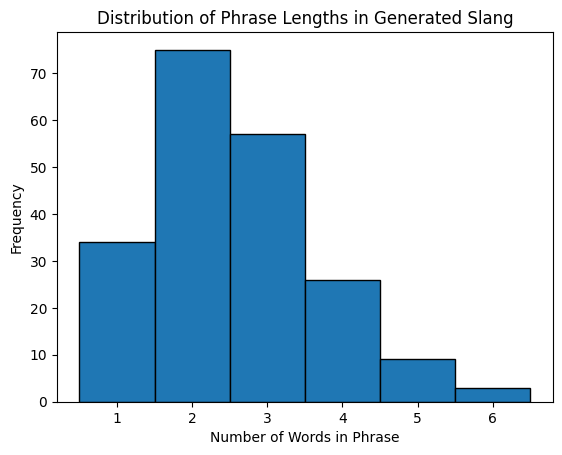

In [34]:
num_words = [len(phrase.split()) for phrase in multi_worded]
num_words_single = [1 for phrase in single_worded]

total_num_words = num_words + num_words_single
plt.hist(total_num_words, bins=range(1, max(total_num_words)+2), align='left', edgecolor='black')
plt.xlabel('Number of Words in Phrase')
plt.ylabel('Frequency')
plt.title('Distribution of Phrase Lengths in Generated Slang')
plt.xticks(range(1, max(total_num_words)+1))
plt.show()

In [18]:
unique_words = []
total_checked = len(single_worded)

for word in single_worded:
    # We assume word_exists(word) returns True if found in Oxford/Urban/Reddit
    # So 'not exists' means the word is unique to your current input
    if not word_exists(word, Silent = True):
        unique_words.append(word)

# Calculate the proportion
proportion_unique = len(unique_words) / total_checked if total_checked > 0 else 0

# Results
print(f"Proportion of unique words: {proportion_unique:.2%}")
print(f"Number of unique words: {len(unique_words)} out of {total_checked}")
print("-" * 30)
print("List of Unique Words:")
print(unique_words)

Proportion of unique words: 8.82%
Number of unique words: 3 out of 34
------------------------------
List of Unique Words:
[' slayage', ' facts', ' mid-tier']


In [31]:
reddit_scores = []

for i in multi_worded[:10]:
    score = reddit_calculate_uniqueness(i, 2, corpus_ngram_freq)
    reddit_scores.append(score)
    print(f"Reddit Commonality Score: {i} {score:.2%}")

Reddit Commonality Score:  vibe check 0.00%
Reddit Commonality Score:  no cap 100.00%
Reddit Commonality Score:  main character 100.00%
Reddit Commonality Score:  glow up 0.00%
Reddit Commonality Score:  stan account 0.00%
Reddit Commonality Score:  chaotic energy 0.00%
Reddit Commonality Score:  fam vibes 0.00%
Reddit Commonality Score:  bussin’ out 0.00%
Reddit Commonality Score:  send tea 0.00%
Reddit Commonality Score:  let’s get it 100.00%


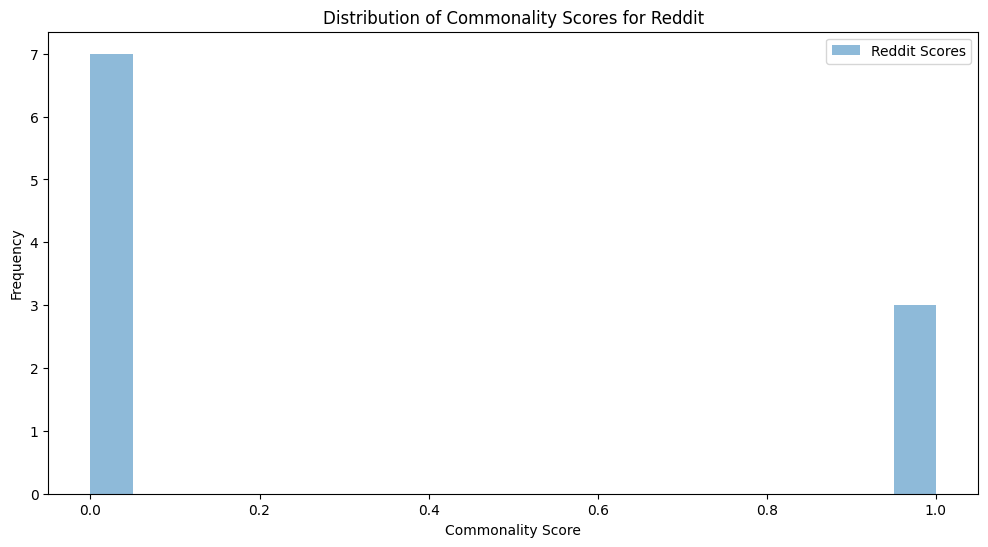

In [ ]:
# histogram of reddit commonality scores
plt.figure(figsize=(12, 6))
plt.hist(reddit_scores, bins=20, alpha=0.5, label='Reddit Scores')
plt.xlabel('Commonality Score')
plt.ylabel('Frequency')
plt.title('Distribution of Commonality Scores for Reddit')
plt.legend()
plt.show()

In [20]:
reddit_tokens = [token for sublist in reddit_tokenized for token in sublist]
reddit_freq = FreqDist(ngrams(reddit_tokens, 2))

# 2. Build Movie Map
movie_tokens = [token for sublist in all_tokens for token in sublist] # assuming you have movie_tokenized
movie_freq = FreqDist(ngrams(movie_tokens, 2))

In [21]:
def calculate_corpus_score(expression, n, freq_dist, label="Corpus"):
    """
    Calculates what percentage of an expression's n-grams exist in a given frequency map.
    """
    expr_tokens = word_tokenize(expression.lower())
    expr_ngrams = list(ngrams(expr_tokens, n))
    
    if not expr_ngrams:
        return 0.0
    
    # Fast O(1) lookup in the frequency map
    present_count = sum(1 for gram in expr_ngrams if gram in freq_dist)
    proportion_present = present_count / len(expr_ngrams)
    
    return proportion_present

In [22]:
test_phrase = "that rizz is actually insane"

# Get scores for both
r_score = calculate_corpus_score(test_phrase, 2, reddit_freq)
m_score = calculate_corpus_score(test_phrase, 2, movie_freq)

print(f"Phrase: {test_phrase}")
print(f"Reddit Commonality: {r_score:.2%}")
print(f"Movie Commonality: {m_score:.2%}")

if r_score > m_score:
    print("Verdict: This sounds more like a Reddit/Social Media comment.")
else:
    print("Verdict: This sounds more like scripted Movie dialogue.")

Phrase: that rizz is actually insane
Reddit Commonality: 50.00%
Movie Commonality: 0.00%
Verdict: This sounds more like a Reddit/Social Media comment.


In [23]:
test_phrase = "hello there"

# Get scores for both
r_score = calculate_corpus_score(test_phrase, 2, reddit_freq)
m_score = calculate_corpus_score(test_phrase, 2, movie_freq)

print(f"Phrase: {test_phrase}")
print(f"Reddit Commonality: {r_score:.2%}")
print(f"Movie Commonality: {m_score:.2%}")

if r_score > m_score:
    print("Verdict: This sounds more like a Reddit/Social Media comment.")
else:
    print("Verdict: This sounds more like scripted Movie dialogue.")

Phrase: hello there
Reddit Commonality: 100.00%
Movie Commonality: 0.00%
Verdict: This sounds more like a Reddit/Social Media comment.


In [24]:
r_scores = []
m_scores = []
rvm = []

for phrase in multi_worded[:10]:
    r_score = calculate_corpus_score(phrase, 2, reddit_freq)
    m_score = calculate_corpus_score(phrase, 2, movie_freq)

    r_scores.append(r_score)
    m_scores.append(m_score)
    
    if r_score > m_score:
        rvm.append(0) # Reddit
    else:
        rvm.append(1) # Movie
    

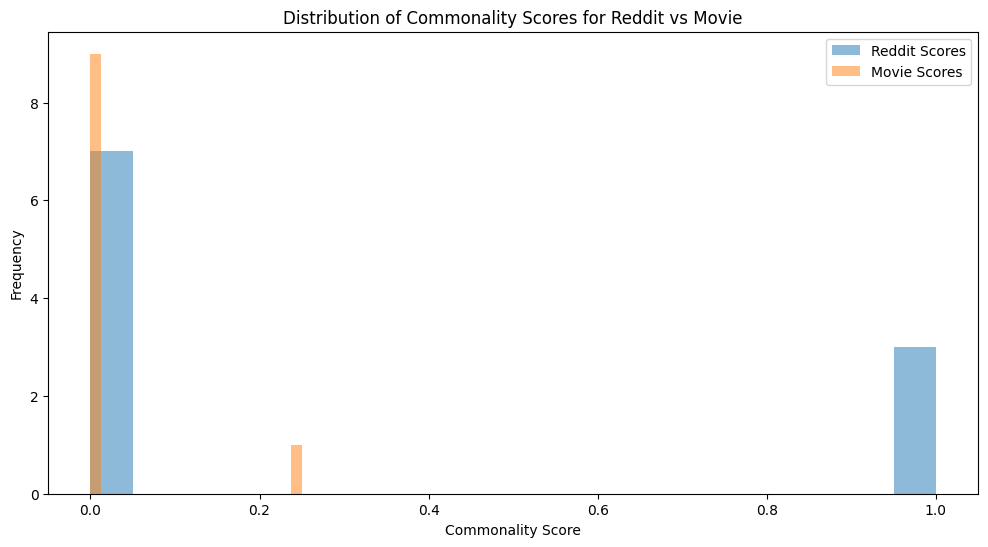

In [ ]:
# histogram of Reddit vs Movie scores
plt.figure(figsize=(12, 6))
plt.hist(r_scores, bins=20, alpha=0.5, label='Reddit Scores')
plt.hist(m_scores, bins=20, alpha=0.5, label='Movie Scores')
plt.xlabel('Commonality Score')
plt.ylabel('Frequency')
plt.title('Distribution of Commonality Scores for Reddit vs Movie')
plt.legend()
plt.show()

In [25]:
#the ngrams still needs some work